In [5]:
import matplotlib.pyplot as plt
import shutil

FONTSIZE = 18
try:
    if shutil.which("latex") is not None:
        plt.rc("text", usetex=True)
        plt.rc(
            "text.latex",
            preamble=r"""
        \usepackage{amsmath}
        \usepackage[bitstream-charter]{mathdesign}
        \DeclareSymbolFont{usualmathcal}{OMS}{cmsy}{m}{n}
        \DeclareSymbolFontAlphabet{\mathcal}{usualmathcal}
        """
        )
        plt.rc("font", family="serif", size=FONTSIZE, serif="Charter")
    else:
        raise RuntimeError("LaTeX not found")
except Exception:
    plt.rc("text", usetex=False)
    plt.rc("font", family="serif", size=FONTSIZE)

plt.rc("axes", titlesize=FONTSIZE)
colors = ["#1f77b4", "#d62728", "#1b9e77", "#2ca02c"]

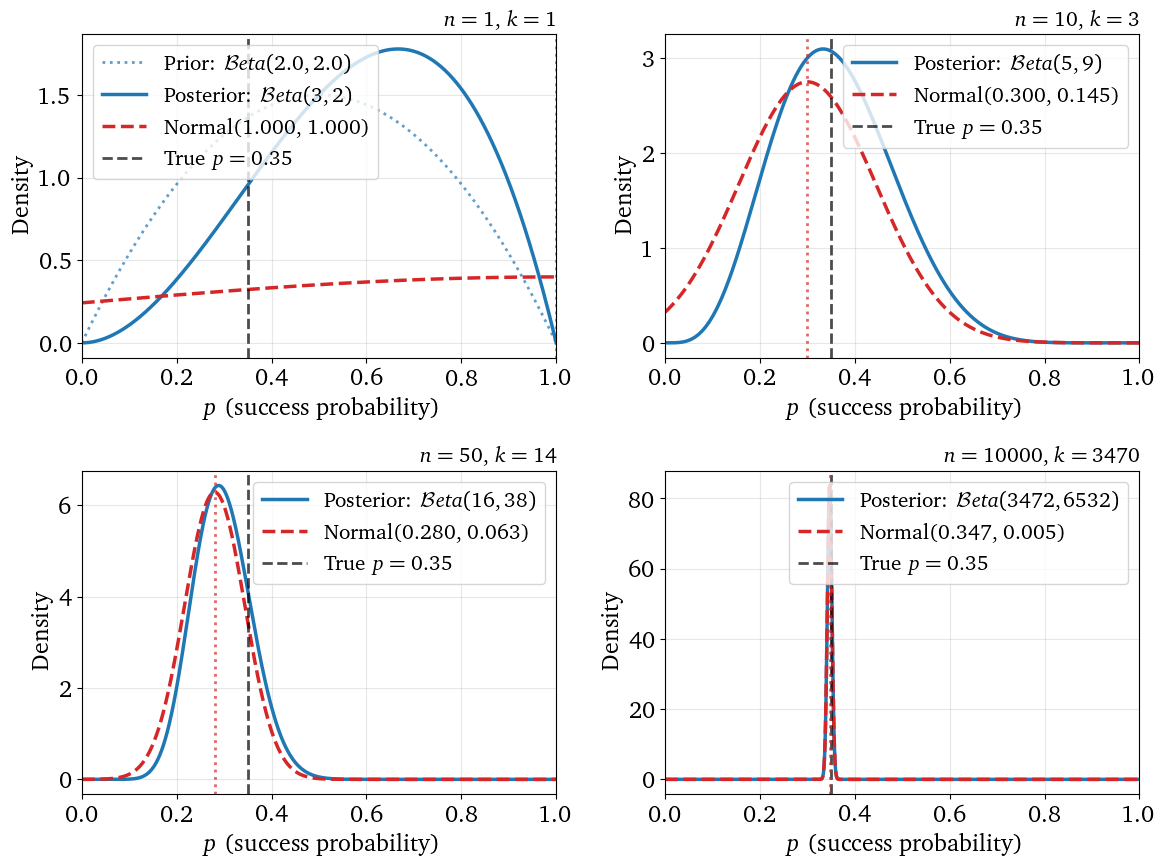


BERNSTEIN-VON MISES: ANALYTICAL BETA POSTERIOR vs ASYMPTOTIC NORMAL
     n      k      MLE  Post Mean     MLE SE    Post SD     KL Div  Wasserstein
--------------------------------------------------------------------------------
     1      0   0.0000     0.4000     1.0000     0.2000   1.253869     0.085436
    10      6   0.6000     0.5714     0.1549     0.1278   0.055803     0.029279
    50     19   0.3800     0.3889     0.0686     0.0657   0.011784     0.008889
 10000   3490   0.3490     0.3491     0.0048     0.0048   0.000094     0.000060

Note: As n → ∞, KL divergence and Wasserstein distance → 0
This demonstrates the Bernstein-von Mises theorem analytically.


In [6]:
import jax.numpy as jnp
from scipy import stats
import numpy as np

# Set random seed
np.random.seed(12345)

# True parameter
true_p = 0.35

# Prior parameters
alpha_prior = 2.0
beta_prior = 2.0

# Sample sizes to demonstrate convergence
sample_sizes = [10, 50, 200, 1000]
sample_sizes = [1, 10, 50, 10_000]


def analytical_posterior(n_successes, n_trials, alpha_prior, beta_prior):
    """Compute analytical Beta posterior"""
    alpha_post = alpha_prior + n_successes
    beta_post = beta_prior + (n_trials - n_successes)
    return alpha_post, beta_post


def mle_normal_approx(n_successes, n_trials):
    """MLE and asymptotic normal approximation"""
    p_mle = n_successes / n_trials
    # Fisher information: I(p) = n / (p(1-p))
    fisher_info = n_trials / (p_mle * (1 - p_mle)) if 0 < p_mle < 1 else n_trials
    se = 1 / np.sqrt(fisher_info)
    return p_mle, se


# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

p_grid = np.linspace(0, 1, 1000)

for idx, n in enumerate(sample_sizes):
    # Generate data
    n_successes = np.random.binomial(n, true_p)

    # Analytical posterior (Beta distribution)
    alpha_post, beta_post = analytical_posterior(
        n_successes, n, alpha_prior, beta_prior
    )
    posterior_beta = stats.beta(alpha_post, beta_post)

    # MLE and asymptotic normal
    p_mle, se_mle = mle_normal_approx(n_successes, n)
    normal_approx = stats.norm(p_mle, se_mle)

    # Prior
    prior_beta = stats.beta(alpha_prior, beta_prior)

    ax = axes[idx]

    # Plot prior (only for first subplot)
    if idx == 0:
        ax.plot(
            p_grid,
            prior_beta.pdf(p_grid),
            colors[0],
            linestyle="dotted",
            linewidth=2,
            label=rf"Prior: $\mathcal{{B}}\mathit{{eta}}({alpha_prior}, {beta_prior})$",
            alpha=0.7
        )

    # Plot analytical posterior
    ax.plot(
        p_grid,
        posterior_beta.pdf(p_grid),
        color=colors[0],
        linewidth=2.5,
        label=rf"Posterior: $\mathcal{{B}}\mathit{{eta}}({alpha_post:.0f}, {beta_post:.0f})$"
    )

    # Plot asymptotic normal approximation
    ax.plot(
        p_grid,
        normal_approx.pdf(p_grid),
        color=colors[1],
        linestyle="--",
        linewidth=2.5,
        label=f"Normal({p_mle:.3f}, {se_mle:.3f})",
    )

    # Mark true value
    ax.axvline(
        true_p,
        color='black',
        linestyle="--",
        linewidth=2,
        label=rf"True $p = {true_p}$",
        alpha=0.7,
    )

    # Mark MLE
    ax.axvline(p_mle, color=colors[1], linestyle=":", linewidth=2.0, alpha=0.7)

    # Compute KL divergence (Beta || Normal)
    # Sample from posterior for numerical KL
    samples = np.linspace(0.001, 0.999, 10000)
    p_beta = posterior_beta.pdf(samples)
    p_norm = normal_approx.pdf(samples)
    # Clip to avoid log(0)
    p_beta = np.clip(p_beta, 1e-10, None)
    p_norm = np.clip(p_norm, 1e-10, None)
    kl_div = np.trapezoid(p_beta * np.log(p_beta / p_norm), samples)

    # Compute Wasserstein distance
    wasserstein = stats.wasserstein_distance(
        samples,
        samples,
        u_weights=p_beta / p_beta.sum(),
        v_weights=p_norm / p_norm.sum(),
    )

    ax.set_xlabel(r"$p$ (success probability)")
    ax.set_ylabel("Density")
    ax.set_title(
        rf"$n = {n}$, $k = {n_successes}$",
        #+ f"KL(Beta || Normal) = {kl_div:.4f}, Wasserstein = {wasserstein:.4f}",
        fontsize=FONTSIZE-2,
        loc="right"
    )
    ax.legend(fontsize=FONTSIZE-2, loc="upper left")
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)

    # Zoom in for large n
    if n >= 5:
        ax.legend(fontsize=FONTSIZE-2, loc="upper right")
        ax.set_xlim(max(0, p_mle - 4 * se_mle), min(1, p_mle + 4 * se_mle))
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("bvm_beta.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Print quantitative comparison
print("\n" + "=" * 80)
print("BERNSTEIN-VON MISES: ANALYTICAL BETA POSTERIOR vs ASYMPTOTIC NORMAL")
print("=" * 80)
print(
    f"{'n':>6} {'k':>6} {'MLE':>8} {'Post Mean':>10} {'MLE SE':>10} "
    f"{'Post SD':>10} {'KL Div':>10} {'Wasserstein':>12}"
)
print("-" * 80)

for n in sample_sizes:
    n_successes = np.random.binomial(n, true_p)

    # Analytical posterior
    alpha_post, beta_post = analytical_posterior(
        n_successes, n, alpha_prior, beta_prior
    )
    post_mean = alpha_post / (alpha_post + beta_post)
    post_var = (alpha_post * beta_post) / (
        (alpha_post + beta_post) ** 2 * (alpha_post + beta_post + 1)
    )
    post_sd = np.sqrt(post_var)

    # MLE approximation
    p_mle, se_mle = mle_normal_approx(n_successes, n)

    # KL divergence
    posterior_beta = stats.beta(alpha_post, beta_post)
    normal_approx = stats.norm(p_mle, se_mle)
    samples = np.linspace(0.001, 0.999, 10000)
    p_beta = posterior_beta.pdf(samples)
    p_norm = normal_approx.pdf(samples)
    p_beta = np.clip(p_beta, 1e-10, None)
    p_norm = np.clip(p_norm, 1e-10, None)
    kl_div = np.trapezoid(p_beta * np.log(p_beta / p_norm), samples)

    # Wasserstein distance
    wasserstein = stats.wasserstein_distance(
        samples,
        samples,
        u_weights=p_beta / p_beta.sum(),
        v_weights=p_norm / p_norm.sum(),
    )

    print(
        f"{n:6d} {n_successes:6d} {p_mle:8.4f} {post_mean:10.4f} "
        f"{se_mle:10.4f} {post_sd:10.4f} {kl_div:10.6f} {wasserstein:12.6f}"
    )

print("\nNote: As n → ∞, KL divergence and Wasserstein distance → 0")
print("This demonstrates the Bernstein-von Mises theorem analytically.")